In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.arff
/kaggle/input/datasets/hassan06/nslkdd/index.html
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.txt
/kaggle/input/datas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]

In [4]:
train_path = "/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt"
test_path = "/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt"

train_df = pd.read_csv(train_path, names=column_names)
test_df = pd.read_csv(test_path, names=column_names)

print("شکل (Shape) دیتای ترین:", train_df.shape)
print("شکل (Shape) دیتای تست:", test_df.shape)

شکل (Shape) دیتای ترین: (125973, 43)
شکل (Shape) دیتای تست: (22544, 43)


In [5]:
train_path = "/kaggle/input/nslkdd/KDDTrain+.txt"
test_path = "/kaggle/input/nslkdd/KDDTest+.txt"

In [6]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [7]:
# دیکشنری (Dictionary) که هر نام حمله رو به دسته‌ی اصلیش نگاشت (Map) می‌کنه
attack_mapping = {
    'normal': 'normal',

    # دسته‌ی DoS
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',

    # دسته‌ی Probe
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'satan': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',

    # دسته‌ی R2L
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'warezclient': 'R2L', 'warezmaster': 'R2L', 'xlock': 'R2L',
    'xsnoop': 'R2L', 'snmpguess': 'R2L', 'snmpgetattack': 'R2L',
    'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    'worm': 'R2L',

    # دسته‌ی U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R',
    'xterm': 'U2R'
}

# ساخت یک ستون جدید به اسم attack_category بر اساس این نگاشت
train_df['attack_category'] = train_df['label'].map(attack_mapping)
test_df['attack_category'] = test_df['label'].map(attack_mapping)

# چک کردن نتیجه
print(train_df['attack_category'].value_counts())

attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [8]:
print("مقادیر خالی در train:", train_df['attack_category'].isnull().sum())
print("مقادیر خالی در test:", test_df['attack_category'].isnull().sum())

مقادیر خالی در train: 0
مقادیر خالی در test: 0


In [9]:
print(train_df['protocol_type'].value_counts())

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64


In [10]:
print(train_df['service'].value_counts().head(15))

service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
ftp          1754
auth          955
Z39_50        862
uucp          780
courier       734
Name: count, dtype: int64


In [11]:
print(train_df['flag'].value_counts())

flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64


In [12]:
pd.crosstab(train_df['flag'], train_df['attack_category'])

attack_category,DoS,Probe,R2L,U2R,normal
flag,,,,,
OTH,0,35,0,0,11
REJ,5671,2869,0,0,2693
RSTO,1216,80,46,1,219
RSTOS0,0,103,0,0,0
RSTR,90,2180,5,0,146
S0,34344,153,0,0,354
S1,2,1,1,0,361
S2,5,2,1,0,119
S3,0,1,3,0,45


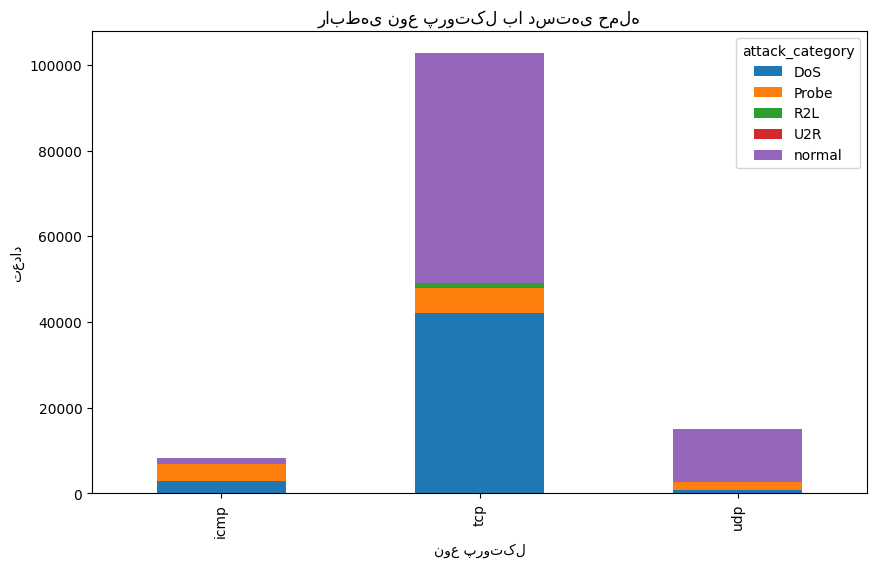

In [13]:
pd.crosstab(train_df['protocol_type'], train_df['attack_category']).plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('رابطه‌ی نوع پروتکل با دسته‌ی حمله')
plt.xlabel('نوع پروتکل')
plt.ylabel('تعداد')
plt.show()

In [14]:
train_df[['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']].describe()

,duration,src_bytes,dst_bytes,count,srv_count
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,84.107555,27.737888
std,2604.51531,5.870331e+06,4.021269e+06,114.508607,72.635840
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,2.000000,2.000000
50%,0.00000,4.400000e+01,0.000000e+00,14.000000,8.000000
75%,0.00000,2.760000e+02,5.160000e+02,143.000000,18.000000
max,42908.00000,1.379964e+09,1.309937e+09,511.000000,511.000000


In [15]:
train_df.groupby('attack_category')[['duration', 'src_bytes', 'dst_bytes', 'count']].mean()

,duration,src_bytes,dst_bytes,count
attack_category,,,,
DoS,0.006227,1176.321162,169.201537,178.090034
Probe,2074.858185,385679.838367,181074.911805,77.052248
R2L,633.417085,307727.300503,81822.026131,1.297487
U2R,80.942308,906.230769,5141.961538,5.807692
normal,168.587396,13133.279331,4329.685223,22.517945


In [16]:
# بخش یک: تبدیل ستون‌های دسته‌ای به عدد
categorical_columns = ['protocol_type', 'service', 'flag']
train_encoded = pd.get_dummies(train_df, columns=categorical_columns)
test_encoded = pd.get_dummies(test_df, columns=categorical_columns)

# بخش دو: هماهنگ کردن ستون‌های ترین و تست
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

# بخش سه: جدا کردن ویژگی‌ها از برچسب
X_train = train_encoded.drop(['label', 'attack_category', 'difficulty'], axis=1)
y_train = train_encoded['attack_category']

X_test = test_encoded.drop(['label', 'attack_category', 'difficulty'], axis=1)
y_test = test_encoded['attack_category']

# بخش چهار: مقیاس‌بندی ویژگی‌های عددی
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# بررسی نهایی
print("شکل X_train:", X_train.shape)
print("شکل X_test:", X_test.shape)
print("شکل y_train:", y_train.shape)
print("شکل y_test:", y_test.shape)

شکل X_train: (125973, 122)
شکل X_test: (22544, 122)
شکل y_train: (125973,)
شکل y_test: (22544,)


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,          # تعداد درخت‌های داخل جنگل
    class_weight='balanced',   # مدیریت داده‌ی نامتوازن
    random_state=42,          # برای اینکه نتیجه هر بار یکسان باشه
    n_jobs=-1                # استفاده از همه‌ی هسته‌های پردازنده برای سرعت بیشتر
)

rf_model.fit(X_train_scaled, y_train)
print("اموزش مدل تمام شد")

y_pred = rf_model.predict(X_test_scaled)


from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("===گزارش کامل ارزیابی===")
print (classification_report(y_test,y_pred))

print("\n===ماتریس درهم ریختگی===")
cm = confusion_matrix(y_test,y_pred,labels=rf_model.classes_)
cm_df=pd.DataFrame(cm, index=rf_model.classes_,columns=rf_model.classes_)
print (cm_df)

feature_importance = pd.DataFrame({
    'feature':X_train.columns,
'importance': rf_model.feature_importances_
}).sort_values('importance',ascending=False)

print("\n======")
print(feature_importance.head(10))


اموزش مدل تمام شد
===گزارش کامل ارزیابی===
              precision    recall  f1-score   support

         DoS       0.96      0.79      0.87      7458
       Probe       0.85      0.60      0.70      2421
         R2L       0.78      0.00      0.01      2887
         U2R       0.33      0.01      0.03        67
      normal       0.64      0.97      0.78      9711

    accuracy                           0.75     22544
   macro avg       0.71      0.48      0.48     22544
weighted avg       0.79      0.75      0.70     22544


===ماتریس درهم ریختگی===
         DoS  Probe  R2L  U2R  normal
DoS     5902     64    0    0    1492
Probe    164   1456    0    0     801
R2L        0      3   14    1    2869
U2R        0      0    4    1      62
normal    67    187    0    1    9456

                         feature  importance
1                      src_bytes    0.088348
29            dst_host_srv_count    0.068930
2                      dst_bytes    0.066479
8                      logged_in 